In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv('../Our Datasets/features_sample_match_new.csv')

start_types_wants = ['pass_interception', 'recovery']

df = df[df['start_type'].isin(start_types_wants)]

cols_to_drop = ['Unique ID', 'match_id', 'event_index', 'frame_anchor', 'rec_player_id', 'rec_team_short', 'start_type', 'end_type', 'event_row_index', 
                'source_file', 'error', 'dist_to_near_goal', 'dist_to_far_goal', 'third_end']

df = df.drop(columns=cols_to_drop)

In [22]:
df.head(5)

,dist_to_attacking_goal,d_nearest_opp,n_opp_within5,d_nearest_team,mean_team_dist,n_forward_options,game_state,team_out_of_possession_phase_type,third_start,max_player_targeted_xthreat,player_targeted_dangerous,n_passing_options_dangerous_not_difficult
0,99.575170,7.026308,0.0,8.593788,31.734731,10.0,drawing,high_block,defensive,0.0024,0.0,0.0
3,34.427403,0.000000,1.0,7.359348,27.331335,9.0,drawing,chaotic,attacking,0.0091,0.0,0.0
9,82.713146,4.389533,1.0,2.603114,13.502075,0.0,drawing,chaotic,attacking,0.0091,0.0,0.0
14,51.188596,2.489598,2.0,6.110491,23.968649,7.0,drawing,chaotic,middle,0.0359,1.0,0.0
19,47.054798,0.982700,1.0,11.608070,23.278395,8.0,drawing,chaotic,middle,0.0359,1.0,0.0


In [23]:
print(df['player_targeted_dangerous'].value_counts())

print(df['n_passing_options_dangerous_not_difficult'].value_counts())


player_targeted_dangerous
0.0    531
1.0    318
Name: count, dtype: int64
n_passing_options_dangerous_not_difficult
0.0    1035
1.0      38
2.0       9
3.0       4
Name: count, dtype: int64


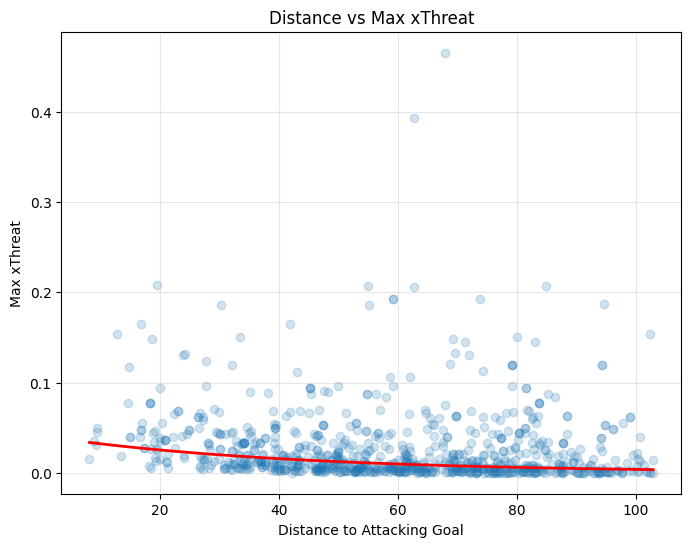

In [24]:
tmp = df[['dist_to_attacking_goal','max_player_targeted_xthreat']].dropna()
x = tmp['dist_to_attacking_goal'].values
y = tmp['max_player_targeted_xthreat'].values

# only positive y for log
mask = y > 0
x = x[mask]
y = y[mask]

# fit log(y)
coef = np.polyfit(x, np.log(y), 1)
b = coef[0]
log_a = coef[1]
a = np.exp(log_a)

# generate xs
xs = np.linspace(x.min(), x.max(), 200)
ys = a * np.exp(b * xs)  # exponential curve

plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.2)
plt.plot(xs, ys, color='red', linewidth=2)

plt.xlabel('Distance to Attacking Goal')
plt.ylabel('Max xThreat')
plt.title('Distance vs Max xThreat')
plt.grid(True, alpha=0.3)

plt.show()

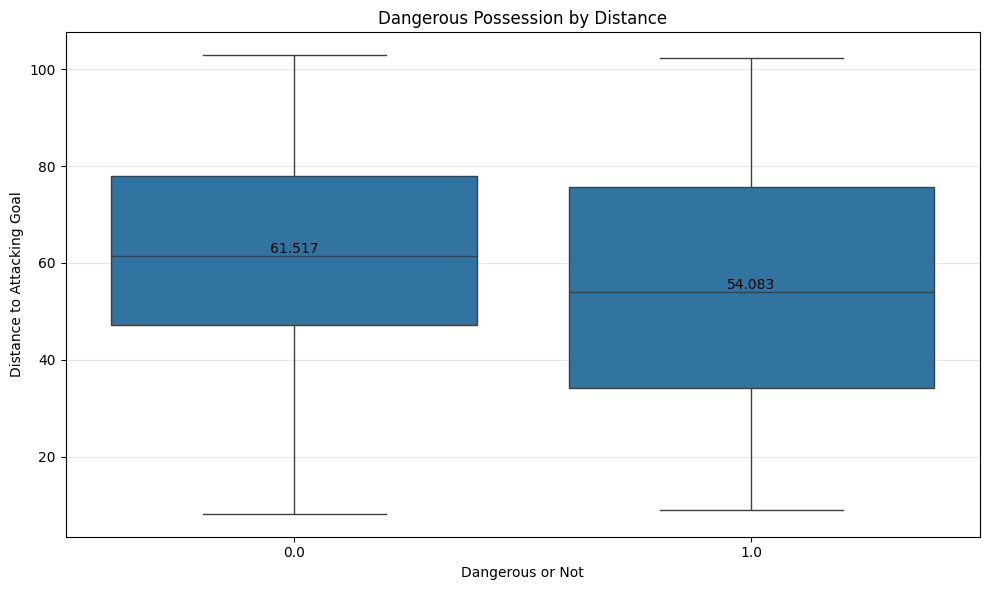

In [25]:
fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(
    data=df,
    x='player_targeted_dangerous',
    y='dist_to_attacking_goal',
    ax=ax
)

medians  = df.groupby('player_targeted_dangerous')['dist_to_attacking_goal'].median()

for tick, label in enumerate(ax.get_xticklabels()):
    opt_text = label.get_text()
    opt_val  = float(opt_text)

    # average
    m = medians.loc[opt_val]
    ax.text(
        tick,
        m,
        f'{m:.3f}',       # label is the mean
        ha='center',
        va='bottom',
        color='black'
    )

ax.set_xlabel('Dangerous or Not')
ax.set_ylabel('Distance to Attacking Goal')
ax.set_title('Dangerous Possession by Distance')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Significant decrease in distance for dangerous possession, same thing above

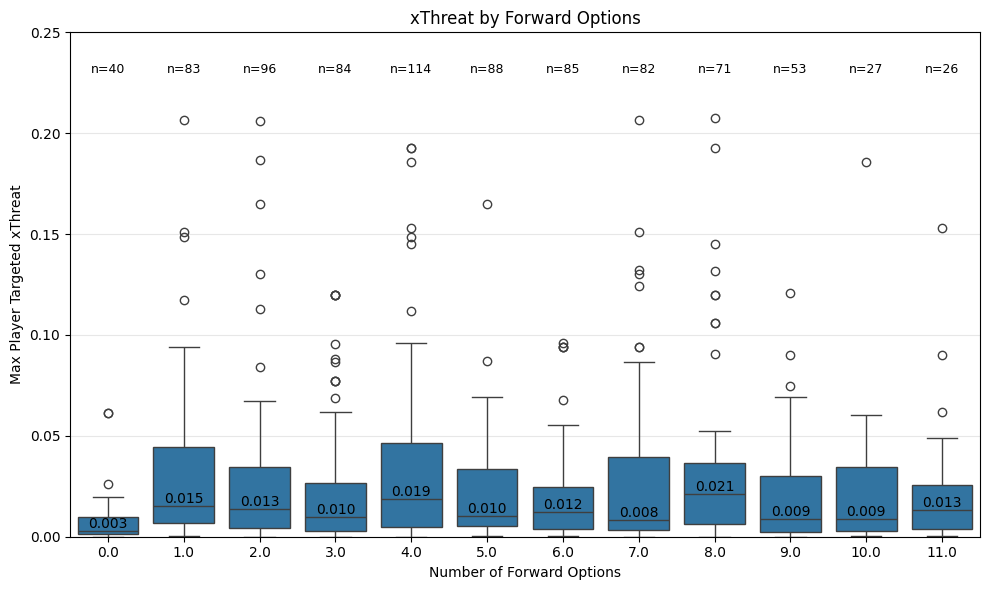

In [26]:
fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(
    data=df,
    x='n_forward_options',
    y='max_player_targeted_xthreat',
    ax=ax
)

counts = df.groupby('n_forward_options')['max_player_targeted_xthreat'].count()
medians  = df.groupby('n_forward_options')['max_player_targeted_xthreat'].median()

for tick, label in enumerate(ax.get_xticklabels()):
    opt_text = label.get_text()
    opt_val  = float(opt_text)

    # average
    m = medians.loc[opt_val]
    ax.text(
        tick,
        m,
        f'{m:.3f}',       # label is the mean
        ha='center',
        va='bottom',
        color='black'
    )

    # count – leave above or remove if you want
    n = counts.loc[opt_val]
    ax.text(
        tick,
        .23,          # slightly above the mean
        f'n={n}',
        ha='center',
        fontsize=9,
        color='black'
    )

ax.set_xlabel('Number of Forward Options')
ax.set_ylabel('Max Player Targeted xThreat')
ax.set_title('xThreat by Forward Options')
ax.grid(axis='y', alpha=0.3)

ax.set_ylim(0, 0.25)

plt.tight_layout()
plt.show()


Not much of a difference in forward options

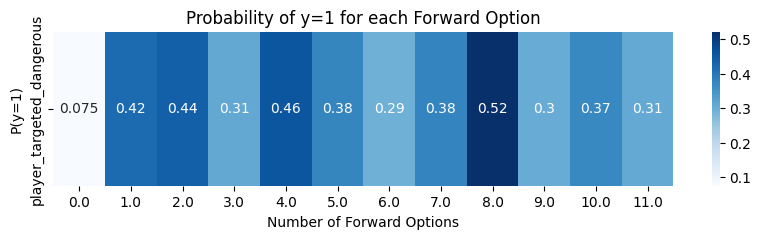

In [27]:
pivot = df.groupby('n_forward_options')['player_targeted_dangerous'].mean().to_frame().T

plt.figure(figsize=(10, 2))
sns.heatmap(pivot, annot=True, cmap="Blues", cbar=True)
plt.xlabel("Number of Forward Options")
plt.ylabel("P(y=1)")
plt.title("Probability of y=1 for each Forward Option")
plt.show()

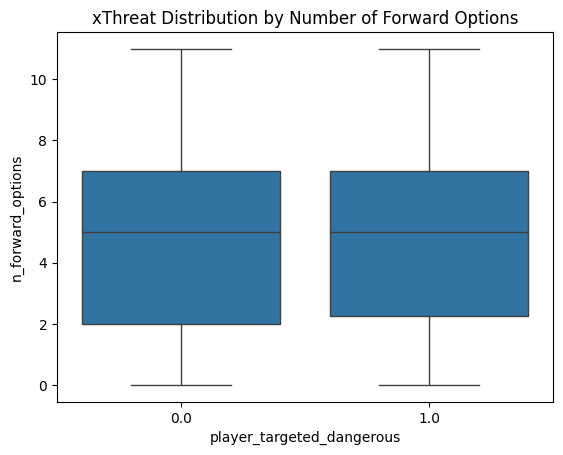

In [28]:
sns.boxplot(x='player_targeted_dangerous', y='n_forward_options', data=df)
plt.title("xThreat Distribution by Number of Forward Options")
plt.show()

Not much of a difference in forward options

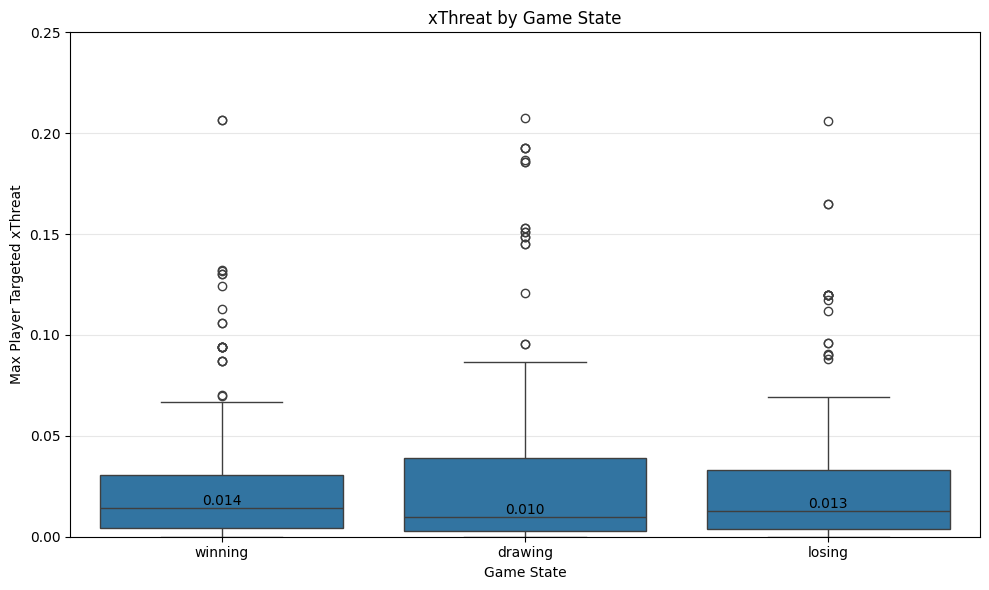

In [29]:
fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(
    data=df,
    x='game_state',
    y='max_player_targeted_xthreat',
    order=['winning','drawing','losing'],   # <-- here
    ax=ax
)

counts = df.groupby('game_state')['max_player_targeted_xthreat'].count()
medians  = df.groupby('game_state')['max_player_targeted_xthreat'].median()

for tick, label in enumerate(ax.get_xticklabels()):
    opt_text = label.get_text()

    # average
    m = medians.loc[opt_text]
    ax.text(
        tick,
        m,
        f'{m:.3f}',       # label is the mean
        ha='center',
        va='bottom',
        color='black'
    )

ax.set_xlabel('Game State')
ax.set_ylabel('Max Player Targeted xThreat')
ax.set_title('xThreat by Game State')
ax.grid(axis='y', alpha=0.3)

ax.set_ylim(0, 0.25)

plt.tight_layout()
plt.show()


Not much fluctuation in game state

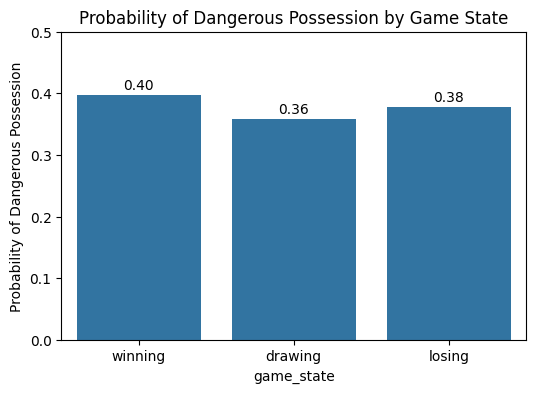

In [30]:
prob = df.groupby('game_state')['player_targeted_dangerous'].mean().reset_index()

plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=prob,
    x='game_state',
    y='player_targeted_dangerous',
    order=['winning','drawing','losing']
)

plt.ylabel("Probability of Dangerous Possession")
plt.title("Probability of Dangerous Possession by Game State")

# --- Add numbers above bars ---
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.2f}",
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 2),   # 5 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')
    
plt.ylim(0, 0.5)

plt.show()


Not much fluctuation in game state

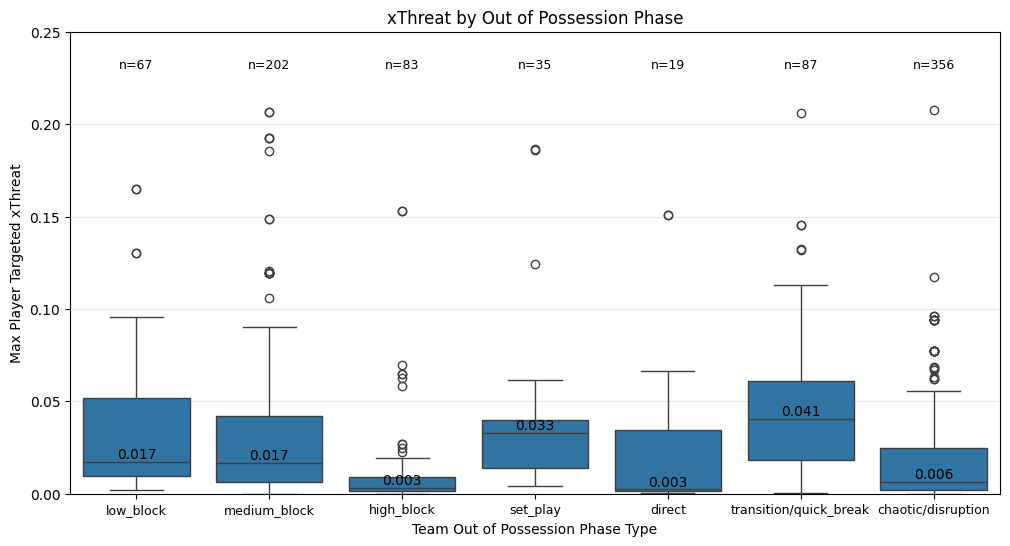

In [31]:
fig, ax = plt.subplots(figsize=(12,6))

df['team_out_of_possession_phase_type'] = (
    df['team_out_of_possession_phase_type']
        .replace({
            'defending_set_play': 'set_play',
            'defending_quick_break': 'transition/quick_break',
            'defending_direct': 'direct',
            'defending_transition': 'transition/quick_break',
            'chaotic': 'chaotic/disruption',
            'disruption': 'chaotic/disruption'
        })
)

sns.boxplot(
    data=df,
    x='team_out_of_possession_phase_type',
    y='max_player_targeted_xthreat',
    order=['low_block','medium_block','high_block', 'set_play', 'direct', 'transition/quick_break', 'chaotic/disruption'],   # <-- here
    ax=ax
)

counts = df.groupby('team_out_of_possession_phase_type')['max_player_targeted_xthreat'].count()
medians  = df.groupby('team_out_of_possession_phase_type')['max_player_targeted_xthreat'].median()

for tick, label in enumerate(ax.get_xticklabels()):
    opt_text = label.get_text()

    # average
    m = medians.loc[opt_text]
    ax.text(
        tick,
        m,
        f'{m:.3f}',       # label is the mean
        ha='center',
        va='bottom',
        color='black'
    )

        # count – leave above or remove if you want
    n = counts.loc[opt_text]
    ax.text(
        tick,
        .23,          # slightly above the mean
        f'n={n}',
        ha='center',
        fontsize=9,
        color='black'
    )

ax.set_xlabel('Team Out of Possession Phase Type')
ax.set_ylabel('Max Player Targeted xThreat')
ax.set_title('xThreat by Out of Possession Phase')
ax.grid(axis='y', alpha=0.3)

plt.xticks(fontsize=9)

ax.set_ylim(0, 0.25)

plt.show()


Looks like high_block, set_play, direct, transition, quick_break, chaotic, and disruption are significant. I think we could combine transition and quick_break and chaotic and disruption.

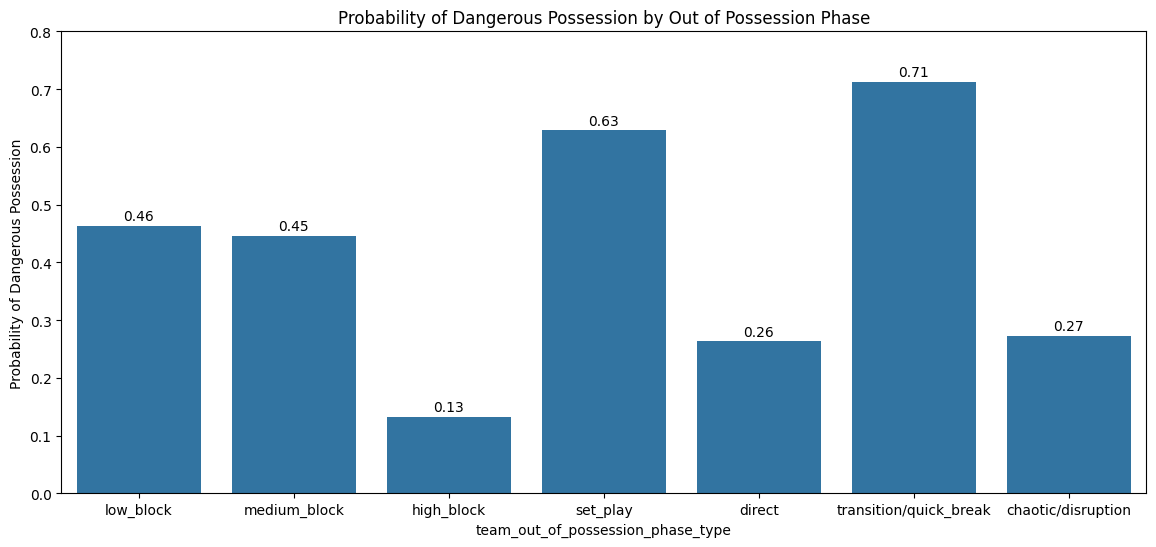

In [32]:
prob = df.groupby('team_out_of_possession_phase_type')['player_targeted_dangerous'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14,6))
ax = sns.barplot(
    data=prob,
    x='team_out_of_possession_phase_type',
    y='player_targeted_dangerous',
    order=['low_block','medium_block','high_block', 'set_play', 'direct', 'transition/quick_break', 'chaotic/disruption']
)

plt.ylabel("Probability of Dangerous Possession")
plt.title("Probability of Dangerous Possession by Out of Possession Phase")

# --- Add numbers above bars ---
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.2f}",
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 2),   # 5 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')
    
plt.ylim(0, .8)

plt.show()

Lots of fluctuation here, especially high_blocks, set plays, transitions, direct play, and chaotic/disruptions

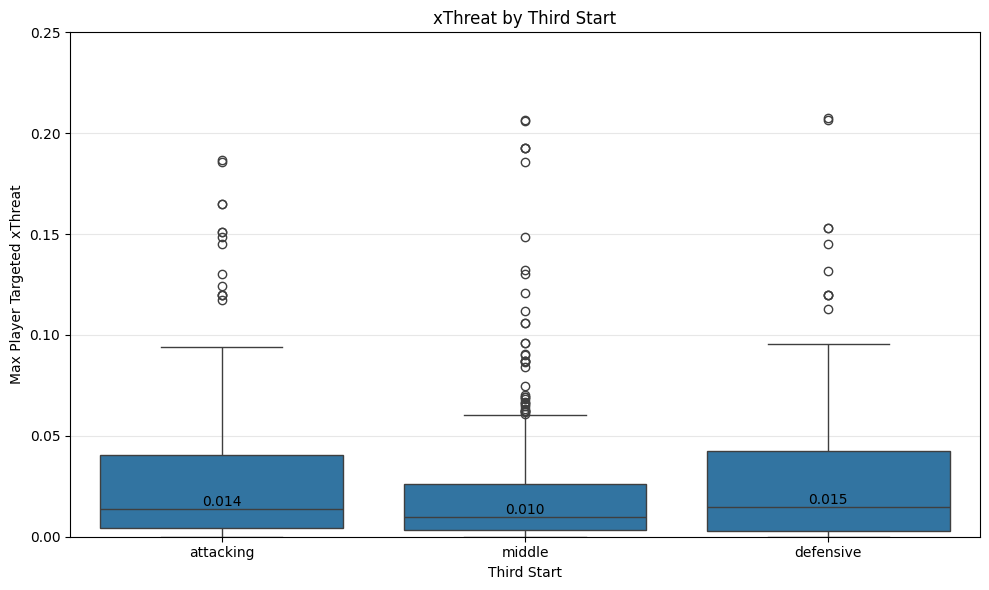

In [33]:
fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(
    data=df,
    x='third_start',
    y='max_player_targeted_xthreat',
    order=['attacking','middle','defensive'],   # <-- here
    ax=ax
)

counts = df.groupby('third_start')['max_player_targeted_xthreat'].count()
medians  = df.groupby('third_start')['max_player_targeted_xthreat'].median()

for tick, label in enumerate(ax.get_xticklabels()):
    opt_text = label.get_text()

    # average
    m = medians.loc[opt_text]
    ax.text(
        tick,
        m,
        f'{m:.3f}',       # label is the mean
        ha='center',
        va='bottom',
        color='black'
    )

ax.set_xlabel('Third Start')
ax.set_ylabel('Max Player Targeted xThreat')
ax.set_title('xThreat by Third Start')
ax.grid(axis='y', alpha=0.3)

ax.set_ylim(0, 0.25)

plt.tight_layout()
plt.show()


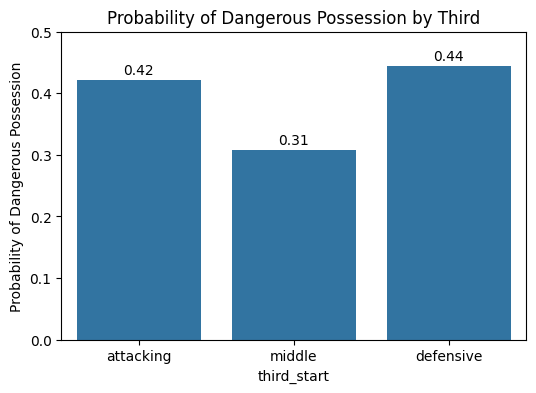

In [34]:
prob = df.groupby('third_start')['player_targeted_dangerous'].mean().reset_index()

plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=prob,
    x='third_start',
    y='player_targeted_dangerous',
    order=['attacking','middle','defensive'],   # <-- here
)

plt.ylabel("Probability of Dangerous Possession")
plt.title("Probability of Dangerous Possession by Third")

# --- Add numbers above bars ---
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.2f}",
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 2),   # 5 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')
    
plt.ylim(0, 0.5)

plt.show()


Why is defensive higher than middle? Looks like middle third means lower probability of a dangerous possession

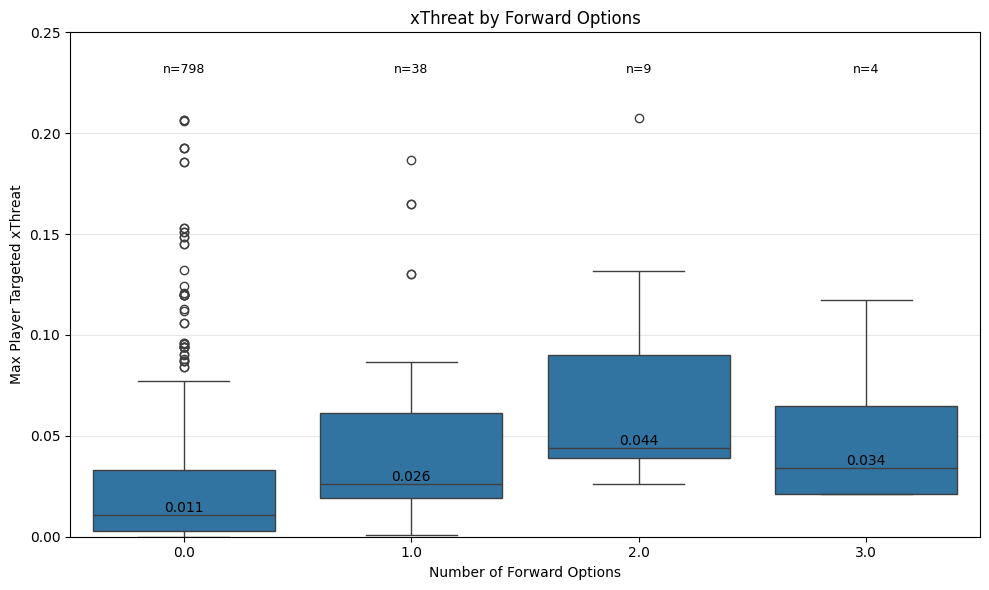

In [35]:
fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(
    data=df,
    x='n_passing_options_dangerous_not_difficult',
    y='max_player_targeted_xthreat',
    ax=ax
)

counts = df.groupby('n_passing_options_dangerous_not_difficult')['max_player_targeted_xthreat'].count()
medians  = df.groupby('n_passing_options_dangerous_not_difficult')['max_player_targeted_xthreat'].median()

for tick, label in enumerate(ax.get_xticklabels()):
    opt_text = label.get_text()
    opt_val  = float(opt_text)

    # average
    m = medians.loc[opt_val]
    ax.text(
        tick,
        m,
        f'{m:.3f}',       # label is the mean
        ha='center',
        va='bottom',
        color='black'
    )

    # count – leave above or remove if you want
    n = counts.loc[opt_val]
    ax.text(
        tick,
        .23,          # slightly above the mean
        f'n={n}',
        ha='center',
        fontsize=9,
        color='black'
    )

ax.set_xlabel('Number of Forward Options')
ax.set_ylabel('Max Player Targeted xThreat')
ax.set_title('xThreat by Forward Options')
ax.grid(axis='y', alpha=0.3)

ax.set_ylim(0, 0.25)

plt.tight_layout()
plt.show()


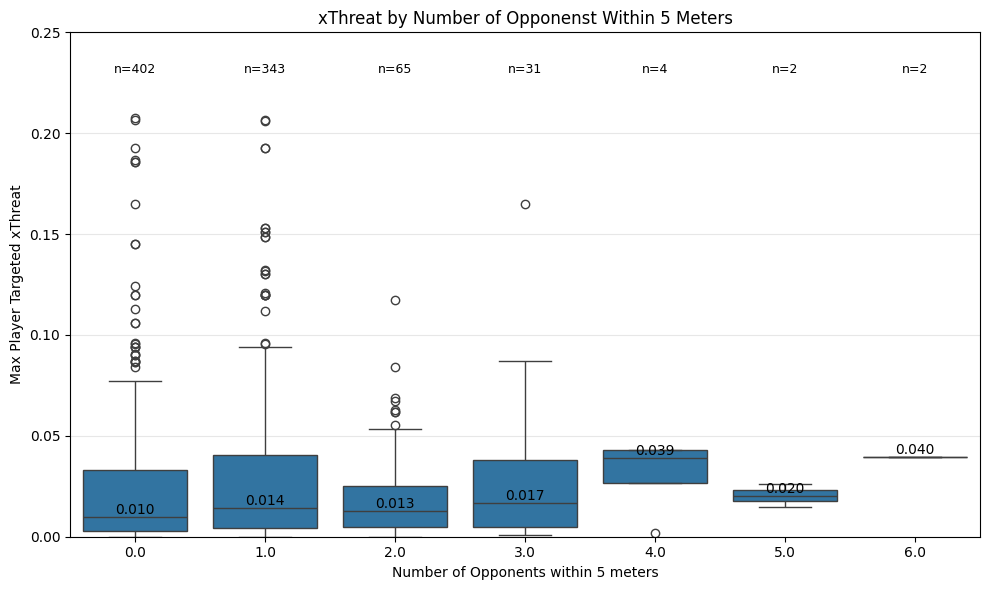

In [43]:
fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(
    data=df,
    x='n_opp_within5',
    y='max_player_targeted_xthreat',
    ax=ax
)

counts = df.groupby('n_opp_within5')['max_player_targeted_xthreat'].count()
medians  = df.groupby('n_opp_within5')['max_player_targeted_xthreat'].median()

for tick, label in enumerate(ax.get_xticklabels()):
    opt_text = label.get_text()
    opt_val  = float(opt_text)

    # average
    m = medians.loc[opt_val]
    ax.text(
        tick,
        m,
        f'{m:.3f}',       # label is the mean
        ha='center',
        va='bottom',
        color='black'
    )

    # count – leave above or remove if you want
    n = counts.loc[opt_val]
    ax.text(
        tick,
        .23,          # slightly above the mean
        f'n={n}',
        ha='center',
        fontsize=9,
        color='black'
    )

ax.set_xlabel('Number of Opponents within 5 meters')
ax.set_ylabel('Max Player Targeted xThreat')
ax.set_title('xThreat by Number of Opponenst Within 5 Meters')
ax.grid(axis='y', alpha=0.3)

ax.set_ylim(0, 0.25)

plt.tight_layout()
plt.show()


# Now we get into less significant variables in my opinion

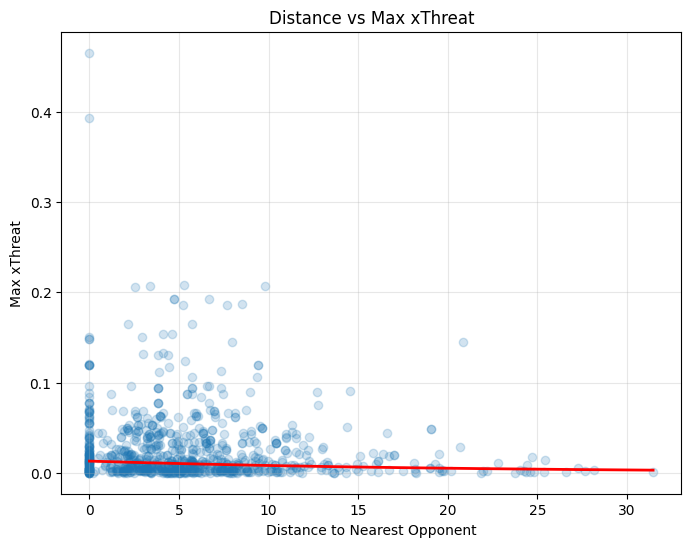

In [36]:
tmp = df[['d_nearest_opp','max_player_targeted_xthreat']].dropna()
x = tmp['d_nearest_opp'].values
y = tmp['max_player_targeted_xthreat'].values

# only positive y for log
mask = y > 0
x = x[mask]
y = y[mask]

# fit log(y)
coef = np.polyfit(x, np.log(y), 1)
b = coef[0]
log_a = coef[1]
a = np.exp(log_a)

# generate xs
xs = np.linspace(x.min(), x.max(), 200)
ys = a * np.exp(b * xs)  # exponential curve

plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.2)
plt.plot(xs, ys, color='red', linewidth=2)

plt.xlabel('Distance to Nearest Opponent')
plt.ylabel('Max xThreat')
plt.title('Distance vs Max xThreat')
plt.grid(True, alpha=0.3)

plt.show()

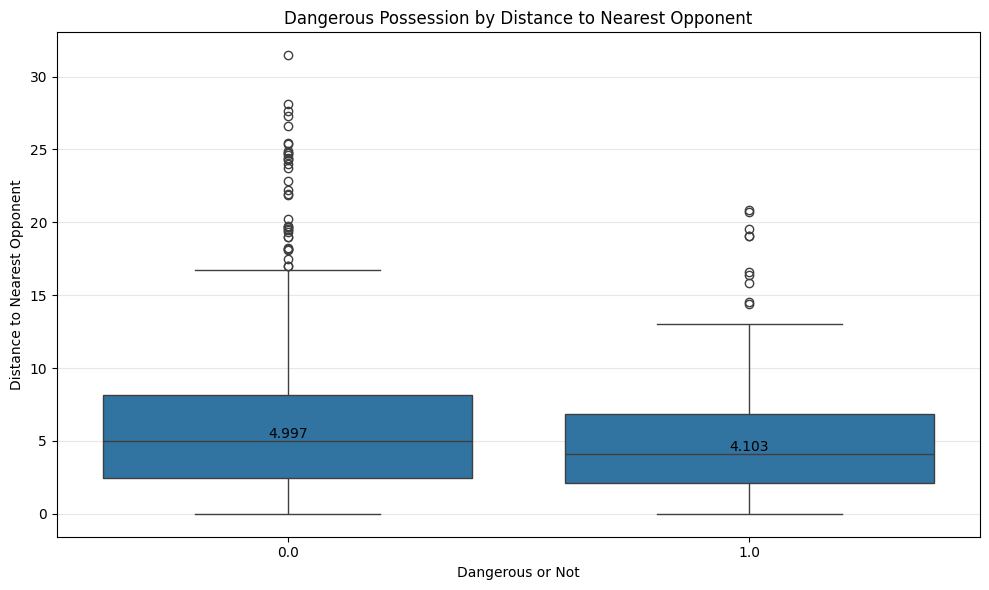

In [37]:
fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(
    data=df,
    x='player_targeted_dangerous',
    y='d_nearest_opp',
    ax=ax
)

medians  = df.groupby('player_targeted_dangerous')['d_nearest_opp'].median()

for tick, label in enumerate(ax.get_xticklabels()):
    opt_text = label.get_text()
    opt_val  = float(opt_text)

    # average
    m = medians.loc[opt_val]
    ax.text(
        tick,
        m,
        f'{m:.3f}',       # label is the mean
        ha='center',
        va='bottom',
        color='black'
    )

ax.set_xlabel('Dangerous or Not')
ax.set_ylabel('Distance to Nearest Opponent')
ax.set_title('Dangerous Possession by Distance to Nearest Opponent')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Not much of a relationship here, maybe slight exponential? Seems as if dangerous possessions have opponents where they are slightly closer to the player when they recover the ball

Seems to be fairly significant, however there aren't enough variables/features

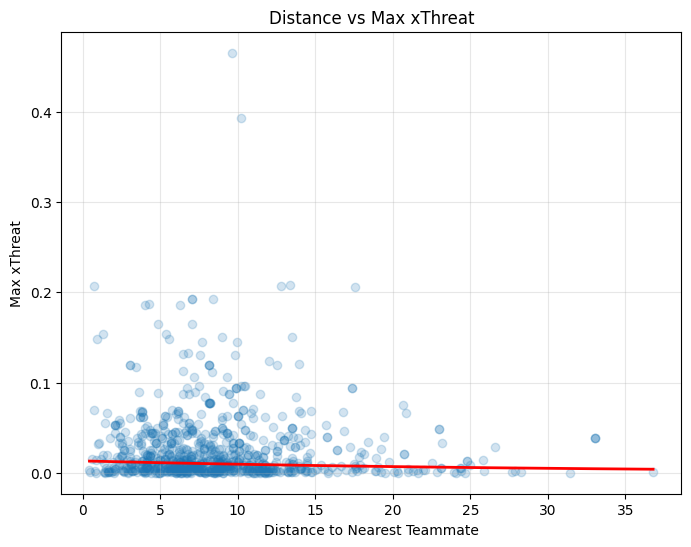

In [38]:
tmp = df[['d_nearest_team','max_player_targeted_xthreat']].dropna()
x = tmp['d_nearest_team'].values
y = tmp['max_player_targeted_xthreat'].values

# only positive y for log
mask = y > 0
x = x[mask]
y = y[mask]

# fit log(y)
coef = np.polyfit(x, np.log(y), 1)
b = coef[0]
log_a = coef[1]
a = np.exp(log_a)

# generate xs
xs = np.linspace(x.min(), x.max(), 200)
ys = a * np.exp(b * xs)  # exponential curve

plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.2)
plt.plot(xs, ys, color='red', linewidth=2)

plt.xlabel('Distance to Nearest Teammate')
plt.ylabel('Max xThreat')
plt.title('Distance vs Max xThreat')
plt.grid(True, alpha=0.3)

plt.show()

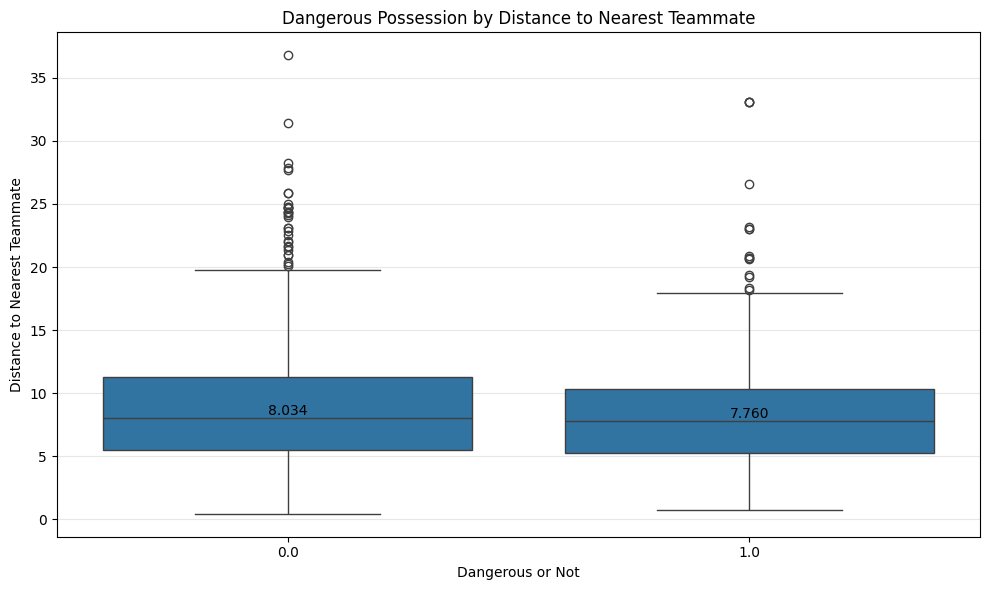

In [39]:
fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(
    data=df,
    x='player_targeted_dangerous',
    y='d_nearest_team',
    ax=ax
)

medians  = df.groupby('player_targeted_dangerous')['d_nearest_team'].median()

for tick, label in enumerate(ax.get_xticklabels()):
    opt_text = label.get_text()
    opt_val  = float(opt_text)

    # average
    m = medians.loc[opt_val]
    ax.text(
        tick,
        m,
        f'{m:.3f}',       # label is the mean
        ha='center',
        va='bottom',
        color='black'
    )

ax.set_xlabel('Dangerous or Not')
ax.set_ylabel('Distance to Nearest Teammate')
ax.set_title('Dangerous Possession by Distance to Nearest Teammate')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

No real relationship here at all with both variables

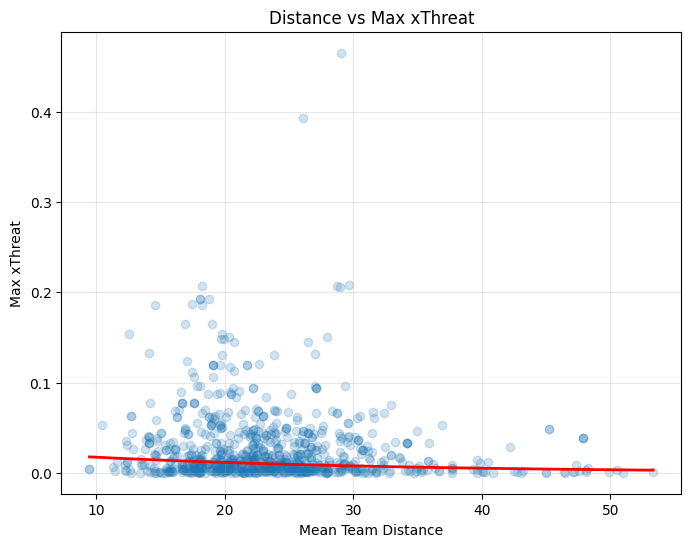

In [40]:
tmp = df[['mean_team_dist','max_player_targeted_xthreat']].dropna()
x = tmp['mean_team_dist'].values
y = tmp['max_player_targeted_xthreat'].values

# only positive y for log
mask = y > 0
x = x[mask]
y = y[mask]

# fit log(y)
coef = np.polyfit(x, np.log(y), 1)
b = coef[0]
log_a = coef[1]
a = np.exp(log_a)

# generate xs
xs = np.linspace(x.min(), x.max(), 200)
ys = a * np.exp(b * xs)  # exponential curve

plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.2)
plt.plot(xs, ys, color='red', linewidth=2)

plt.xlabel('Mean Team Distance')
plt.ylabel('Max xThreat')
plt.title('Distance vs Max xThreat')
plt.grid(True, alpha=0.3)

plt.show()

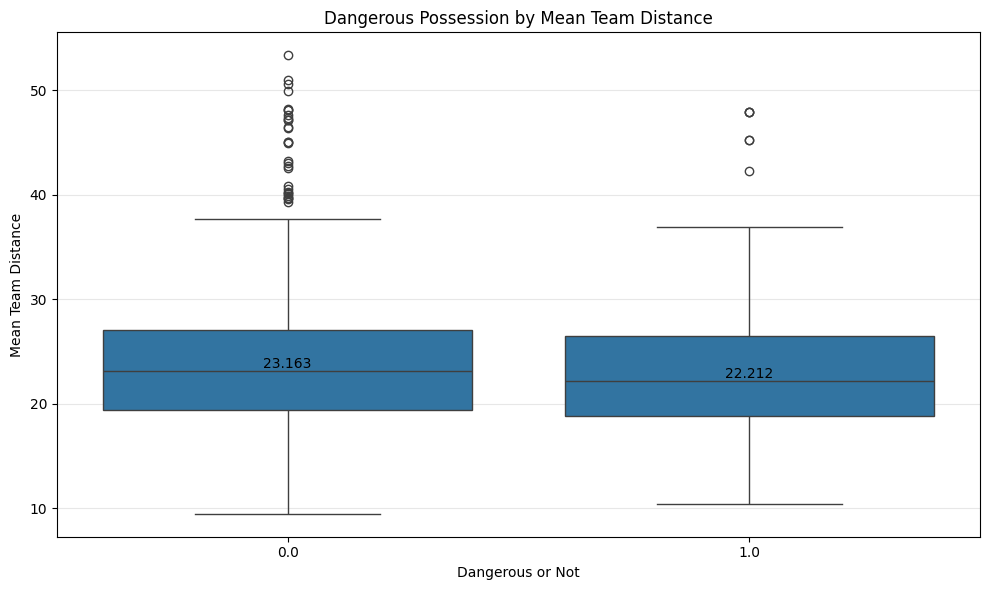

In [41]:
fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(
    data=df,
    x='player_targeted_dangerous',
    y='mean_team_dist',
    ax=ax
)

medians  = df.groupby('player_targeted_dangerous')['mean_team_dist'].median()

for tick, label in enumerate(ax.get_xticklabels()):
    opt_text = label.get_text()
    opt_val  = float(opt_text)

    # average
    m = medians.loc[opt_val]
    ax.text(
        tick,
        m,
        f'{m:.3f}',       # label is the mean
        ha='center',
        va='bottom',
        color='black'
    )

ax.set_xlabel('Dangerous or Not')
ax.set_ylabel('Mean Team Distance')
ax.set_title('Dangerous Possession by Mean Team Distance')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Again not much of a relationship, maybe slightly lower team distance but this is splitting hairs